In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.linear_model import LinearRegression,ElasticNet,Lasso,Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor,GradientBoostingRegressor,RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [2]:
df=pd.read_csv("train.csv")

In [3]:
df.head()

,event_time,event_type,product_id,category_id,user_id,user_session,session_value
0,2025-06-19 10:23:07+00:00,ADD_CART,PROD_011223,CAT_00054,USER_097562,SESSION_158779,90.29
1,2025-06-07 21:34:45+00:00,ADD_CART,PROD_005519,CAT_00144,USER_006535,SESSION_029987,16.39
2,2025-06-21 21:29:09+00:00,ADD_CART,PROD_000577,CAT_00273,USER_047199,SESSION_022134,64.27
3,2025-06-09 09:10:20+00:00,ADD_CART,PROD_019235,CAT_00442,USER_082028,SESSION_161308,41.67
4,2025-06-19 11:13:58+00:00,ADD_CART,PROD_001702,CAT_00025,USER_096574,SESSION_182859,86.11


In [4]:
# 1. Veri tipleri ve temel bilgiler
print(df.info())
print(df.describe(include="all"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141219 entries, 0 to 141218
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     141219 non-null  object 
 1   event_type     141219 non-null  object 
 2   product_id     141219 non-null  object 
 3   category_id    141219 non-null  object 
 4   user_id        141219 non-null  object 
 5   user_session   141219 non-null  object 
 6   session_value  141219 non-null  float64
dtypes: float64(1), object(6)
memory usage: 7.5+ MB
None
                       event_time event_type   product_id category_id  \
count                      141219     141219       141219      141219   
unique                     128357          4        26470         448   
top     2025-06-15 12:00:35+00:00       VIEW  PROD_005510   CAT_00090   
freq                           17      58829          359        6861   
mean                          NaN        NaN          NaN      

In [5]:
# 2. Eksik değer analizi
df.isnull().sum()

event_time       0
event_type       0
product_id       0
category_id      0
user_id          0
user_session     0
session_value    0
dtype: int64

In [6]:
# 3. Kategorik sütunlarda dağılım
print("Event type dağılımı:")
print(df["event_type"].value_counts())

Event type dağılımı:
event_type
VIEW           58829
ADD_CART       42304
REMOVE_CART    25615
BUY            14471
Name: count, dtype: int64


In [7]:
print("En çok sepete eklenen ilk 10 kategori:")
print(df["category_id"].value_counts().head(10))

En çok sepete eklenen ilk 10 kategori:
category_id
CAT_00090    6861
CAT_00046    5016
CAT_00010    5006
CAT_00030    4660
CAT_00027    4041
CAT_00011    3880
CAT_00025    3634
CAT_00013    2952
CAT_00308    2914
CAT_00280    2812
Name: count, dtype: int64


In [8]:
print("En çok sepete eklenen ilk 10 ürün:")
print(df["product_id"].value_counts().head(10))

En çok sepete eklenen ilk 10 ürün:
product_id
PROD_005510    359
PROD_032827    330
PROD_008353    301
PROD_008391    275
PROD_014428    267
PROD_013130    254
PROD_029741    243
PROD_024488    242
PROD_022837    237
PROD_004457    236
Name: count, dtype: int64


In [9]:
print("Kaç farklı kullanıcı var:", df["user_id"].nunique())
print("Kaç farklı session var:", df["user_session"].nunique())

Kaç farklı kullanıcı var: 51821
Kaç farklı session var: 70736


In [10]:
# 4. Zaman analizi
df["event_time"] = pd.to_datetime(df["event_time"])
df["event_date"] = df["event_time"].dt.date
df["event_hour"] = df["event_time"].dt.hour

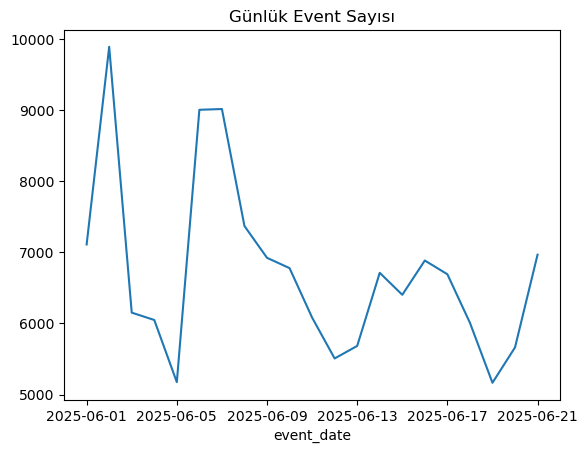

In [11]:
# Gün bazlı event sayısı
events_per_day = df.groupby("event_date")["user_id"].count()
events_per_day.plot(kind="line", title="Günlük Event Sayısı")
plt.show()

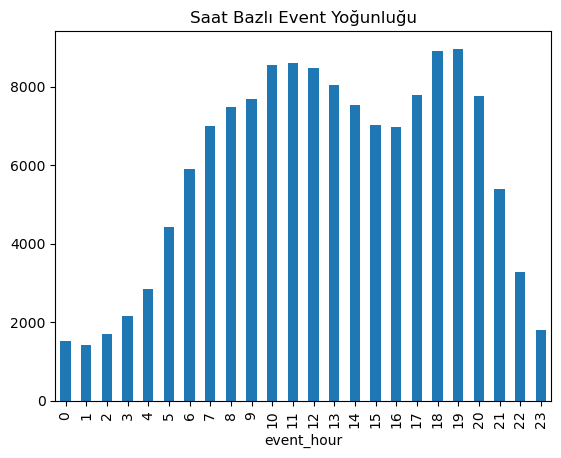

In [12]:
# Saat bazlı yoğunluk
events_per_hour = df.groupby("event_hour")["user_id"].count()
events_per_hour.plot(kind="bar", title="Saat Bazlı Event Yoğunluğu")
plt.show()

In [13]:
# 5. Session_value analizi
print(df["session_value"].describe())

count    141219.000000
mean         75.348539
std         121.794683
min           5.380000
25%          23.780000
50%          40.950000
75%          86.440000
max        2328.660000
Name: session_value, dtype: float64


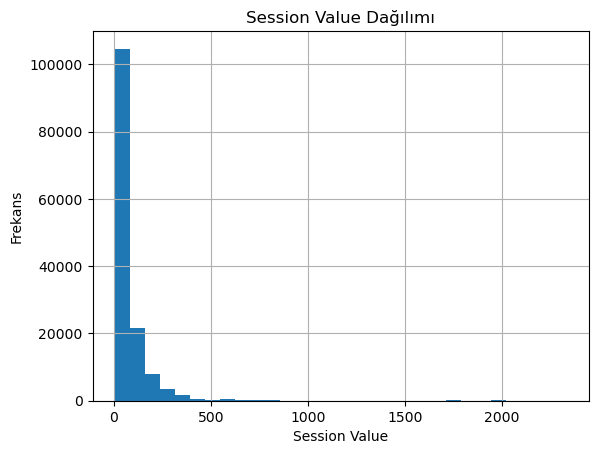

In [14]:
df["session_value"].hist(bins=30)
plt.title("Session Value Dağılımı")
plt.xlabel("Session Value")
plt.ylabel("Frekans")
plt.show()


In [15]:
# 6. Kullanıcı başına istatistikler
user_value = df.groupby("user_id")["session_value"].sum().sort_values(ascending=False)
print("En yüksek toplam harcama yapan ilk 10 kullanıcı:")
print(user_value.head(10))

En yüksek toplam harcama yapan ilk 10 kullanıcı:
user_id
USER_005285    202932.72
USER_046288    200511.99
USER_009033    111775.68
USER_008768     74404.44
USER_084696     55989.00
USER_048383     34653.12
USER_017084     32226.81
USER_078681     31870.10
USER_015331     30275.10
USER_096670     29499.13
Name: session_value, dtype: float64


In [16]:
# 7. Kategori bazlı session value
category_value = df.groupby("category_id")["session_value"].mean().sort_values(ascending=False)
print("Kategori bazlı ortalama session value:")
print(category_value.head(10))


Kategori bazlı ortalama session value:
category_id
CAT_00317    320.775455
CAT_00193    285.991154
CAT_00449    277.264286
CAT_00224    214.534595
CAT_00446    211.444167
CAT_00306    173.833684
CAT_00212    163.851538
CAT_00184    158.253333
CAT_00362    154.520000
CAT_00202    152.812708
Name: session_value, dtype: float64


In [17]:
df["event_date"].unique()

array([datetime.date(2025, 6, 19), datetime.date(2025, 6, 7),
       datetime.date(2025, 6, 21), datetime.date(2025, 6, 9),
       datetime.date(2025, 6, 6), datetime.date(2025, 6, 16),
       datetime.date(2025, 6, 14), datetime.date(2025, 6, 20),
       datetime.date(2025, 6, 5), datetime.date(2025, 6, 4),
       datetime.date(2025, 6, 17), datetime.date(2025, 6, 15),
       datetime.date(2025, 6, 13), datetime.date(2025, 6, 10),
       datetime.date(2025, 6, 1), datetime.date(2025, 6, 2),
       datetime.date(2025, 6, 18), datetime.date(2025, 6, 8),
       datetime.date(2025, 6, 3), datetime.date(2025, 6, 12),
       datetime.date(2025, 6, 11)], dtype=object)

In [18]:
df.head()

,event_time,event_type,product_id,category_id,user_id,user_session,session_value,event_date,event_hour
0,2025-06-19 10:23:07+00:00,ADD_CART,PROD_011223,CAT_00054,USER_097562,SESSION_158779,90.29,2025-06-19,10
1,2025-06-07 21:34:45+00:00,ADD_CART,PROD_005519,CAT_00144,USER_006535,SESSION_029987,16.39,2025-06-07,21
2,2025-06-21 21:29:09+00:00,ADD_CART,PROD_000577,CAT_00273,USER_047199,SESSION_022134,64.27,2025-06-21,21
3,2025-06-09 09:10:20+00:00,ADD_CART,PROD_019235,CAT_00442,USER_082028,SESSION_161308,41.67,2025-06-09,9
4,2025-06-19 11:13:58+00:00,ADD_CART,PROD_001702,CAT_00025,USER_096574,SESSION_182859,86.11,2025-06-19,11


In [19]:
df["event_day"] = df["event_time"].dt.day
df["event_year"] = df["event_time"].dt.year
df["event_month"] = df["event_time"].dt.month

In [20]:
df.head()

,event_time,event_type,product_id,category_id,user_id,user_session,session_value,event_date,event_hour,event_day,event_year,event_month
0,2025-06-19 10:23:07+00:00,ADD_CART,PROD_011223,CAT_00054,USER_097562,SESSION_158779,90.29,2025-06-19,10,19,2025,6
1,2025-06-07 21:34:45+00:00,ADD_CART,PROD_005519,CAT_00144,USER_006535,SESSION_029987,16.39,2025-06-07,21,7,2025,6
2,2025-06-21 21:29:09+00:00,ADD_CART,PROD_000577,CAT_00273,USER_047199,SESSION_022134,64.27,2025-06-21,21,21,2025,6
3,2025-06-09 09:10:20+00:00,ADD_CART,PROD_019235,CAT_00442,USER_082028,SESSION_161308,41.67,2025-06-09,9,9,2025,6
4,2025-06-19 11:13:58+00:00,ADD_CART,PROD_001702,CAT_00025,USER_096574,SESSION_182859,86.11,2025-06-19,11,19,2025,6


In [21]:
df.drop(["event_time","event_date"],axis=1,inplace=True)

In [22]:
df.head()

,event_type,product_id,category_id,user_id,user_session,session_value,event_hour,event_day,event_year,event_month
0,ADD_CART,PROD_011223,CAT_00054,USER_097562,SESSION_158779,90.29,10,19,2025,6
1,ADD_CART,PROD_005519,CAT_00144,USER_006535,SESSION_029987,16.39,21,7,2025,6
2,ADD_CART,PROD_000577,CAT_00273,USER_047199,SESSION_022134,64.27,21,21,2025,6
3,ADD_CART,PROD_019235,CAT_00442,USER_082028,SESSION_161308,41.67,9,9,2025,6
4,ADD_CART,PROD_001702,CAT_00025,USER_096574,SESSION_182859,86.11,11,19,2025,6


In [23]:
df.shape

(141219, 10)

In [24]:
X=df.drop("session_value",axis=1)
y=df["session_value"]


X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=15)


# ---- 1) Prefix temizleme fonksiyonu ----
def remove_prefix(series, prefix):
    return series.str.replace(prefix, "", regex=True).astype(int)

def clean_ids(X):
    X = X.copy()
    X["product_id"] = remove_prefix(X["product_id"], "PROD_")
    X["category_id"] = remove_prefix(X["category_id"], "CAT_")
    X["user_id"] = remove_prefix(X["user_id"], "USER_")
    X["user_session"] = remove_prefix(X["user_session"], "SESSION_")
    return X

# Sklearn için transformer
id_cleaner = FunctionTransformer(clean_ids)

# ---- 2) OneHotEncoder sadece event_type için ----
onehot = OneHotEncoder(handle_unknown="ignore")

# ---- 3) Pipeline ----
preprocessor = ColumnTransformer(
    transformers=[
        ("event_type", onehot, ["event_type"]),
        ("id_cleaner", id_cleaner, ["product_id", "category_id", "user_id", "user_session"])
    ],
    remainder="passthrough"  # diğer sütunları bırak (event_time vs.)
)

# Pipeline: önce preprocessor uygula
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor)
])

# ---- 4) Fit & Transform ----
X_train_processed = pipeline.fit_transform(X_train)
X_test_processed = pipeline.transform(X_test)

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

X_train_processed shape: (98853, 12)
X_test_processed shape: (42366, 12)


In [25]:
# OneHotEncoder çıkan kolonlar
ohe = pipeline.named_steps["preprocessor"].named_transformers_["event_type"]
ohe_features = ohe.get_feature_names_out(["event_type"])  

# id_cleaner sonrası kolon adları (sadece 4 kolon)
id_features = ["product_id", "category_id", "user_id", "user_session"]

# Passthrough kalan kolonlar
# Örnek olarak event_hour, event_day, event_year, event_month
remainder_features = ["event_hour", "event_day", "event_year", "event_month"]

# Tüm feature adlarını birleştir
all_features = list(ohe_features) + id_features + remainder_features

# DataFrame'e kolon adlarını ver
X_train = pd.DataFrame(X_train_processed, columns=all_features, index=X_train.index)
X_test = pd.DataFrame(X_test_processed, columns=all_features, index=X_test.index)

print(X_train.head())


       event_type_ADD_CART  event_type_BUY  event_type_REMOVE_CART  \
19105                  1.0             0.0                     0.0   
45827                  0.0             0.0                     0.0   
469                    1.0             0.0                     0.0   
32348                  1.0             0.0                     0.0   
42180                  1.0             0.0                     0.0   

       event_type_VIEW  product_id  category_id  user_id  user_session  \
19105              0.0      5835.0        285.0  80272.0      133303.0   
45827              1.0     18158.0         27.0  36246.0       51279.0   
469                0.0      4539.0        145.0  82784.0      144298.0   
32348              0.0     17002.0         25.0  27138.0      137641.0   
42180              0.0     25504.0         88.0  19658.0       95652.0   

       event_hour  event_day  event_year  event_month  
19105        10.0        8.0      2025.0          6.0  
45827         6.0     

In [26]:
# Frequency Encoding fonksiyonu
def frequency_encoding(train_col, test_col):
    freq = train_col.value_counts() / len(train_col)
    train_encoded = train_col.map(freq)
    test_encoded = test_col.map(freq).fillna(0)  # test setinde görülmemiş kategori için 0
    return train_encoded, test_encoded

# product_id
X_train["product_id"], X_test["product_id"] = frequency_encoding(X_train["product_id"], X_test["product_id"])

# category_id
X_train["category_id"], X_test["category_id"] = frequency_encoding(X_train["category_id"], X_test["category_id"])

In [27]:
X_train.columns

Index(['event_type_ADD_CART', 'event_type_BUY', 'event_type_REMOVE_CART',
       'event_type_VIEW', 'product_id', 'category_id', 'user_id',
       'user_session', 'event_hour', 'event_day', 'event_year', 'event_month'],
      dtype='object')

In [28]:
# Önce int'e çevir
for col in ["event_year", "event_month", "event_day", "event_hour"]:
    X_train[col] = X_train[col].astype(int)
    X_test[col] = X_test[col].astype(int)

# datetime objesi oluştur
X_train["event_datetime"] = pd.to_datetime({
    "year": X_train["event_year"],
    "month": X_train["event_month"],
    "day": X_train["event_day"],
    "hour": X_train["event_hour"],
    "minute": 0,
    "second": 0
})

X_test["event_datetime"] = pd.to_datetime({
    "year": X_test["event_year"],
    "month": X_test["event_month"],
    "day": X_test["event_day"],
    "hour": X_test["event_hour"],
    "minute": 0,
    "second": 0
})

# is_weekend
X_train["is_weekend"] = (X_train["event_datetime"].dt.weekday >= 5).astype(int)
X_test["is_weekend"] = (X_test["event_datetime"].dt.weekday >= 5).astype(int)

# is_night (0-6 saatleri)
X_train["is_night"] = X_train["event_datetime"].dt.hour.isin(range(0,7)).astype(int)
X_test["is_night"] = X_test["event_datetime"].dt.hour.isin(range(0,7)).astype(int)

# season
def month_to_season(month):
    if month in [12,1,2]: return 0
    elif month in [3,4,5]: return 1
    elif month in [6,7,8]: return 2
    else: return 3

X_train["season"] = X_train["event_month"].apply(month_to_season)
X_test["season"] = X_test["event_month"].apply(month_to_season)

# Gereksiz datetime kolonu kaldır
X_train.drop("event_datetime", axis=1, inplace=True)
X_test.drop("event_datetime", axis=1, inplace=True)

In [29]:
X_train.head()

,event_type_ADD_CART,event_type_BUY,event_type_REMOVE_CART,event_type_VIEW,product_id,category_id,user_id,user_session,event_hour,event_day,event_year,event_month,is_weekend,is_night,season
19105,1.0,0.0,0.0,0.0,0.000121,0.012878,80272.0,133303.0,10,8,2025,6,1,0,2
45827,0.0,0.0,0.0,1.0,0.000233,0.028760,36246.0,51279.0,6,11,2025,6,0,1,2
469,1.0,0.0,0.0,0.0,0.001285,0.008133,82784.0,144298.0,16,9,2025,6,0,0,2
32348,1.0,0.0,0.0,0.0,0.000010,0.025563,27138.0,137641.0,16,8,2025,6,1,0,2
42180,1.0,0.0,0.0,0.0,0.000020,0.006140,19658.0,95652.0,20,9,2025,6,0,0,2


In [30]:
# Kullanıcının toplam işlemleri
user_event_count = X_train.groupby("user_id").size().rename("user_event_count")
X_train = X_train.merge(user_event_count, on="user_id", how="left")
X_test = X_test.merge(user_event_count, on="user_id", how="left")  # train verisine göre merge

# Kullanıcının baktığı farklı ürün sayısı
user_unique_products = X_train.groupby("user_id")["product_id"].nunique().rename("user_unique_products")
X_train = X_train.merge(user_unique_products, on="user_id", how="left")
X_test = X_test.merge(user_unique_products, on="user_id", how="left")

# Ürünün toplam görüntülenme sayısı
product_view_count = X_train.groupby("product_id")["event_type_VIEW"].sum().rename("product_view_count")
X_train = X_train.merge(product_view_count, on="product_id", how="left")
X_test = X_test.merge(product_view_count, on="product_id", how="left")

# Ürünün buy / view oranı
product_buy_count = X_train.groupby("product_id")["event_type_BUY"].sum()
product_buy_ratio = (product_buy_count / product_view_count).fillna(0).rename("product_buy_ratio")
X_train = X_train.merge(product_buy_ratio, on="product_id", how="left")
X_test = X_test.merge(product_buy_ratio, on="product_id", how="left")

# Ürün için ortalama session uzunluğu
avg_session_length = X_train.groupby("product_id")["user_session"].nunique().rename("avg_session_length")
X_train = X_train.merge(avg_session_length, on="product_id", how="left")
X_test = X_test.merge(avg_session_length, on="product_id", how="left")


# Ürünün toplam görüntülenme sayısı
product_view_count = X_train.groupby("product_id")["event_type_VIEW"].sum().rename("product_view_count")
X_train = X_train.merge(product_view_count, on="product_id", how="left")
X_test = X_test.merge(product_view_count, on="product_id", how="left")

# Ürünün buy / view oranı
product_buy_count = X_train.groupby("product_id")["event_type_BUY"].sum()
product_buy_ratio = (product_buy_count / product_view_count).fillna(0).rename("product_buy_ratio")
X_train = X_train.merge(product_buy_ratio, on="product_id", how="left")
X_test = X_test.merge(product_buy_ratio, on="product_id", how="left")

# Ürün için ortalama session uzunluğu
avg_session_length = X_train.groupby("product_id")["user_session"].nunique().rename("avg_session_length")
X_train = X_train.merge(avg_session_length, on="product_id", how="left")
X_test = X_test.merge(avg_session_length, on="product_id", how="left")

In [31]:
# Scaling yapılacak kolonlar
cols_to_scale = [
    "product_view_count_x", "product_buy_ratio_x", "avg_session_length_x",
    "product_view_count_y", "product_buy_ratio_y", "avg_session_length_y"
]

# Scaler oluştur
scaler = StandardScaler()

# Fit & transform sadece train üzerinde
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# Test set için sadece transform uygula
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [35]:
X_train.head()

,event_type_ADD_CART,event_type_BUY,event_type_REMOVE_CART,event_type_VIEW,product_id,category_id,user_id,user_session,event_hour,event_day,...,is_night,season,user_event_count,user_unique_products,product_view_count_x,product_buy_ratio_x,avg_session_length_x,product_view_count_y,product_buy_ratio_y,avg_session_length_y
0,1.0,0.0,0.0,0.0,0.000121,0.012878,80272.0,133303.0,10,8,...,0,2,1,1,-0.600913,0.010534,-0.587531,-0.600913,0.010534,-0.587531
1,0.0,0.0,0.0,1.0,0.000233,0.028760,36246.0,51279.0,6,11,...,1,2,3,2,-1.038024,-0.128915,-1.073774,-1.038024,-0.128915,-1.073774
2,1.0,0.0,0.0,0.0,0.001285,0.008133,82784.0,144298.0,16,9,...,0,2,7,7,-1.271294,12.850685,-1.287384,-1.271294,12.850685,-1.287384
3,1.0,0.0,0.0,0.0,0.000010,0.025563,27138.0,137641.0,16,8,...,0,2,10,7,1.446114,-0.626495,1.418928,1.446114,-0.626495,1.418928
4,1.0,0.0,0.0,0.0,0.000020,0.006140,19658.0,95652.0,20,9,...,0,2,4,4,1.574592,-0.413345,1.521517,1.574592,-0.413345,1.521517


In [45]:
# Sayısal kolonlar (NaN içerebilecek)
num_cols = [
    "user_event_count", "user_unique_products",
    "product_view_count_x", "product_buy_ratio_x", "avg_session_length_x",
    "product_view_count_y", "product_buy_ratio_y", "avg_session_length_y"
]

# Preprocessing pipeline
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),  # NaN -> mean
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ("num", num_transformer, num_cols)
], remainder="passthrough")  # diğer kolonları olduğu gibi bırak

# Modelleri dictionary olarak tanımlayalım
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    "LightGBM": LGBMRegressor(random_state=42, n_jobs=-1),
    "AdaBoost": AdaBoostRegressor(random_state=42)
}

results = []

for name, model in models.items():
    print(f"Training {name}...")

    # Pipeline: Preprocessing + Model
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("regressor", model)
    ])

    # Modeli eğit
    pipeline.fit(X_train, y_train)
    
    # Tahmin
    y_pred = pipeline.predict(X_test)
    
    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "model_object": pipeline  # tuning için kullanabiliriz
    })

# Sonuçları DataFrame olarak göster
results_df = pd.DataFrame(results).sort_values("RMSE")
print(results_df[["model","RMSE","MAE","R2"]])

Training LinearRegression...
Training Ridge...
Training Lasso...
Training DecisionTree...
Training RandomForest...
Training GradientBoosting...
Training XGBoost...
Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001511 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1590
[LightGBM] [Info] Number of data points in the train set: 98853, number of used features: 20
[LightGBM] [Info] Start training from score 75.521124


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Training AdaBoost...
              model        RMSE         MAE        R2
4      RandomForest   50.731418   34.709995  0.821838
6           XGBoost   51.045714   36.168423  0.819623
7          LightGBM   57.757349   39.369075  0.769072
3      DecisionTree   70.041049   35.039340  0.660400
5  GradientBoosting   71.240012   46.241234  0.648674
0  LinearRegression  102.560646   50.011331  0.271845
1             Ridge  102.561239   50.011164  0.271837
2             Lasso  102.749064   50.101024  0.269167
8          AdaBoost  213.808211  188.685139 -2.164543


In [48]:
import warnings
warnings.filterwarnings("ignore")  # Tüm uyarıları kapat


# ----- RANDOM FOREST -----
rf_params = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf = RandomForestRegressor(random_state=42)

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=20,
    cv=5,
    scoring='neg_mean_absolute_error',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)

rf_best = rf_random.best_estimator_
y_pred_rf = rf_best.predict(X_test)

print("---- RANDOM FOREST ----")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2:", r2_score(y_test, y_pred_rf))
print("Best Params:", rf_random.best_params_)

# ----- XGBOOST -----
xgb_params = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1],
    'colsample_bytree': [0.6, 0.8, 1]
}

xgb = XGBRegressor(random_state=42, objective='reg:squarederror')

xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=20,
    cv=5,
    scoring='neg_mean_absolute_error',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X_train, y_train)

xgb_best = xgb_random.best_estimator_
y_pred_xgb = xgb_best.predict(X_test)

print("---- XGBOOST ----")
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("R2:", r2_score(y_test, y_pred_xgb))
print("Best Params:", xgb_random.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END model__colsample_bytree=0.8, model__gamma=0.1, model__learning_rate=0.2, model__max_depth=7, model__n_estimators=100, model__subsample=1.0; total time=   0.8s
[CV] END model__colsample_bytree=0.8, model__gamma=0.1, model__learning_rate=0.1, model__max_depth=10, model__n_estimators=200, model__subsample=0.6; total time=   4.8s
[CV] END model__colsample_bytree=1.0, model__gamma=0, model__learning_rate=0.1, model__max_depth=3, model__n_estimators=300, model__subsample=0.6; total time=   1.5s
[CV] END model__colsample_bytree=0.6, model__gamma=0.5, model__learning_rate=0.05, model__max_depth=7, model__n_estimators=500, model__subsample=0.8; total time=   4.9s
[CV] END model__colsample_bytree=0.8, model__gamma=1, model__learning_rate=0.1, model__max_depth=10, model__n_estimators=300, model__subsample=0.6; total time=   7.9s
[CV] END model__colsample_bytree=0.8, model__gamma=0, model__learning_rate=0.01, model__max_depth=3

Exception ignored in: <function ResourceTracker.__del__ at 0x107391bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


[CV] END model__max_depth=30, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=300; total time=  32.2s
[CV] END model__max_depth=10, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=500; total time=  28.9s
[CV] END model__max_depth=30, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=300; total time=  32.0s
[CV] END model__max_depth=None, model__max_features=auto, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=200; total time=   0.2s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=100; total time=  10.3s
[CV] END model__colsample_bytree=0.8, model__gamma=0.5, model__learning_rate=0.1, model__max_depth=10, model__n_estimators=500, model__subsample=0.8; total time=  12.6s
[CV] END model__colsample_bytree=0.8, model__gamma=0

Exception ignored in: <function ResourceTracker.__del__ at 0x110169bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=500; total time= 1.1min
[CV] END model__colsample_bytree=0.8, model__gamma=0, model__learning_rate=0.05, model__max_depth=10, model__n_estimators=300, model__subsample=1.0; total time=   6.9s
[CV] END model__colsample_bytree=1.0, model__gamma=0, model__learning_rate=0.1, model__max_depth=3, model__n_estimators=300, model__subsample=0.6; total time=   1.5s
[CV] END model__colsample_bytree=1.0, model__gamma=1, model__learning_rate=0.05, model__max_depth=3, model__n_estimators=500, model__subsample=0.6; total time=   2.4s
[CV] END model__colsample_bytree=0.6, model__gamma=0.5, model__learning_rate=0.05, model__max_depth=7, model__n_estimators=500, model__subsample=0.8; total time=   5.0s
[CV] END model__colsample_bytree=0.8, model__gamma=1, model__learning_rate=0.1, model__max_depth=10, model__n_estimators=300, model__subsample=0.6; total time=   9.1s
[CV] E

...

[CV] END model__colsample_bytree=0.8, model__gamma=0.1, model__learning_rate=0.2, model__max_depth=7, model__n_estimators=100, model__subsample=1.0; total time=   1.1s
[CV] END model__colsample_bytree=0.8, model__gamma=0.1, model__learning_rate=0.1, model__max_depth=10, model__n_estimators=200, model__subsample=0.6; total time=   5.3s
[CV] END model__colsample_bytree=1.0, model__gamma=1, model__learning_rate=0.05, model__max_depth=3, model__n_estimators=500, model__subsample=0.6; total time=   2.4s
[CV] END model__colsample_bytree=0.6, model__gamma=0.5, model__learning_rate=0.05, model__max_depth=7, model__n_estimators=500, model__subsample=0.8; total time=   5.1s
[CV] END model__colsample_bytree=1.0, model__gamma=1, model__learning_rate=0.01, model__max_depth=5, model__n_estimators=500, model__subsample=1.0; total time=   4.1s
[CV] END model__colsample_bytree=0.6, model__gamma=0, model__learning_rate=0.1, model__max_depth=7, model__n_estimators=500, model__subsample=0.8; total time=  

Exception ignored in: <function ResourceTracker.__del__ at 0x102d8dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


[CV] END model__max_depth=None, model__max_features=auto, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=200; total time=   0.3s
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=100; total time=   9.9s
[CV] END model__colsample_bytree=0.8, model__gamma=0, model__learning_rate=0.05, model__max_depth=10, model__n_estimators=300, model__subsample=1.0; total time=   7.2s
[CV] END model__colsample_bytree=1.0, model__gamma=0, model__learning_rate=0.1, model__max_depth=3, model__n_estimators=300, model__subsample=0.6; total time=   1.5s
[CV] END model__colsample_bytree=1.0, model__gamma=1, model__learning_rate=0.05, model__max_depth=3, model__n_estimators=500, model__subsample=0.6; total time=   2.4s
[CV] END model__colsample_bytree=0.8, model__gamma=0.5, model__learning_rate=0.05, model__max_depth=10, model__n_estimators=100, model__subsample=1.0; total time=   2.6s
[CV] END model__

Exception ignored in: <function ResourceTracker.__del__ at 0x104d81bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106c09bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106069bc0>
Traceback (most recent call last

---- RANDOM FOREST ----
MAE: 21.943952780531568
RMSE: 37.77001330625157
R2: 0.9012455881706699
Best Params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': None}
Fitting 5 folds for each of 20 candidates, totalling 100 fits
---- XGBOOST ----
MAE: 74.77101894001976
RMSE: 124.35743863224059
R2: -0.07054707159385432
Best Params: {'subsample': 1, 'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [49]:
print("MSE:", mean_squared_error(y_test, y_pred_rf))

MSE: 1426.5739051544206
